# ============================================================
# TASK 3: Energy Consumption Time Series Forecasting
# DevelopersHub Corporation – Data Science Internship
# ============================================================

In [1]:
!pip install prophet scikit-learn xgboost statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
!unzip -q household_power_consumption.zip

df_raw = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    dayfirst=True,
    low_memory=False,
    na_values=['?']
)

print("Dataset loaded!")
print(f"Shape: {df_raw.shape}")
print(df_raw.head())
print(f"\nDate range: {df_raw['Datetime'].min()} → {df_raw['Datetime'].max()}")


Dataset loaded!
Shape: (2075259, 8)
             Datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00


In [4]:
df_raw.set_index('Datetime', inplace=True)

# Use Global_active_power as our target
df_raw['Global_active_power'] = pd.to_numeric(df_raw['Global_active_power'], errors='coerce')

# Drop rows with missing target
df_raw.dropna(subset=['Global_active_power'], inplace=True)

# Resample to HOURLY average (reduces noise, manageable size)
df_hourly = df_raw['Global_active_power'].resample('H').mean()

# Drop any remaining NaN after resampling
df_hourly.dropna(inplace=True)

print(f"Resampled to hourly data")
print(f"Total hourly records: {len(df_hourly)}")
print(f"Date range: {df_hourly.index.min()} → {df_hourly.index.max()}")
print(df_hourly.head(10))


Resampled to hourly data
Total hourly records: 34168
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00
Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
2006-12-16 22:00:00    2.200133
2006-12-16 23:00:00    2.061600
2006-12-17 00:00:00    1.882467
2006-12-17 01:00:00    3.349400
2006-12-17 02:00:00    1.587267
Name: Global_active_power, dtype: float64


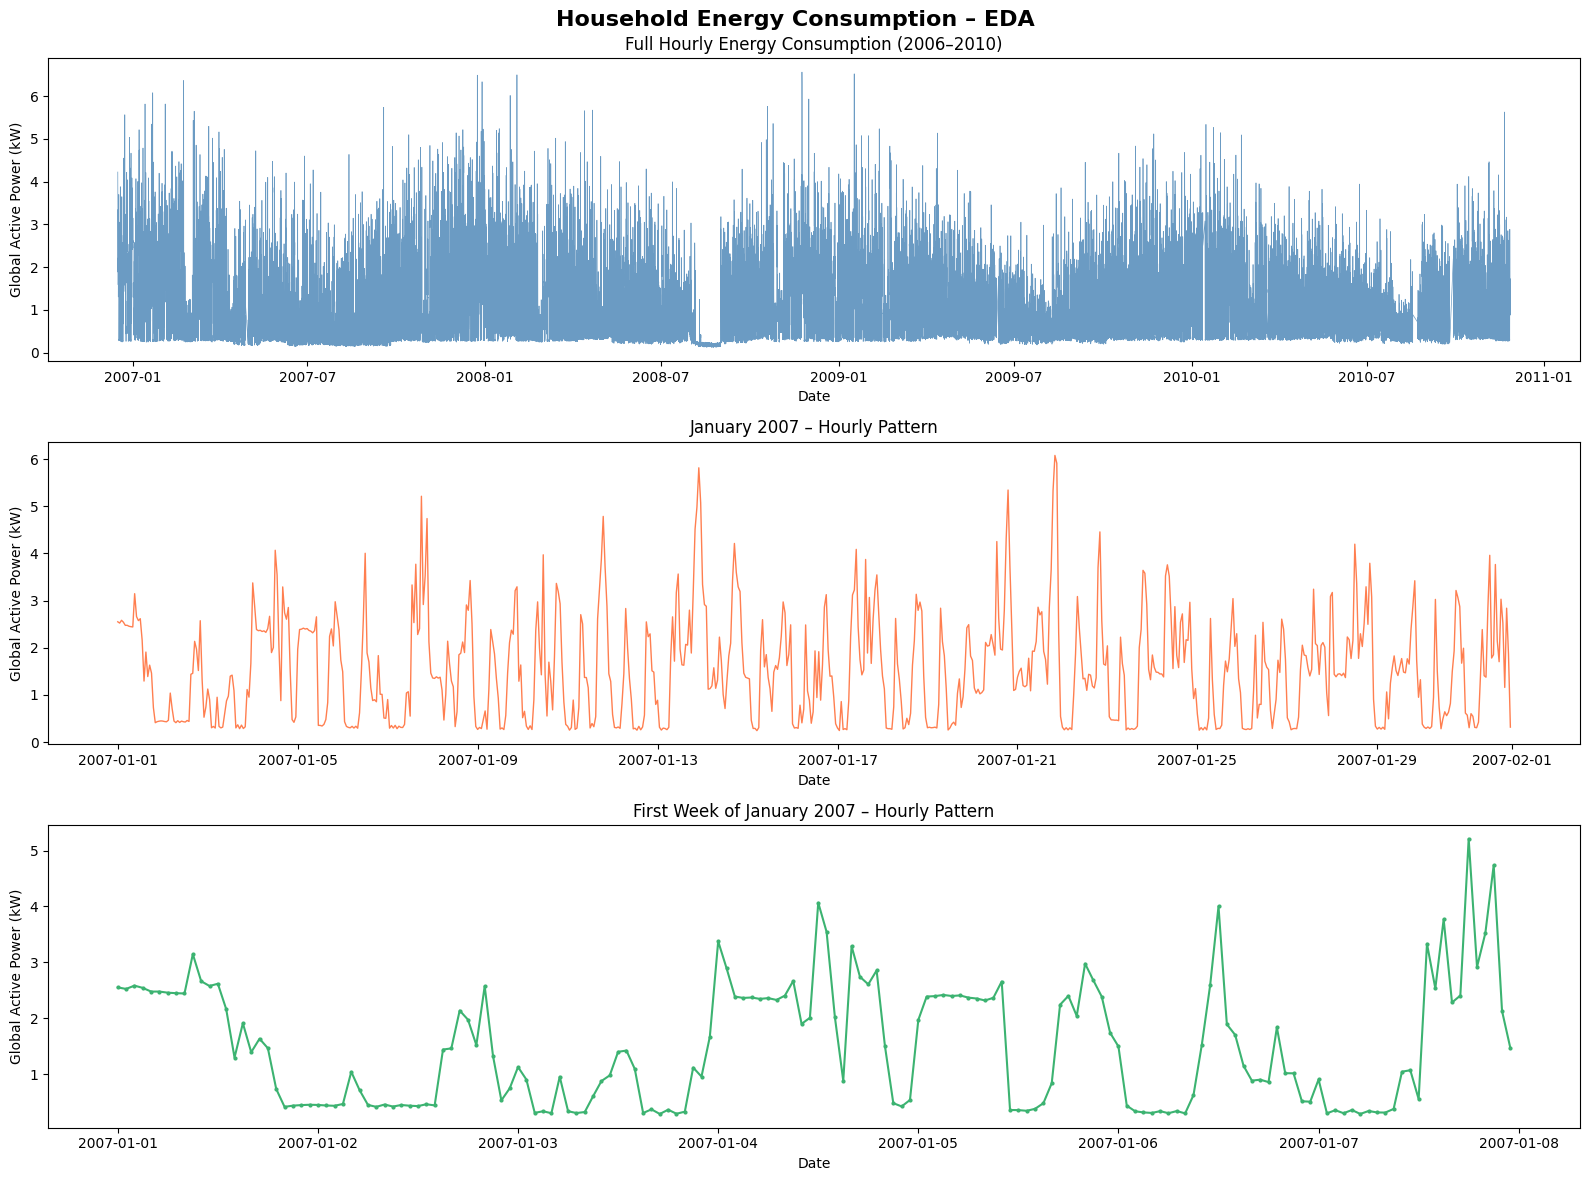

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Household Energy Consumption – EDA', fontsize=16, fontweight='bold')

# Full series
axes[0].plot(df_hourly.index, df_hourly.values, color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Full Hourly Energy Consumption (2006–2010)')
axes[0].set_ylabel('Global Active Power (kW)')
axes[0].set_xlabel('Date')

# One month zoom
one_month = df_hourly['2007-01':'2007-01']
axes[1].plot(one_month.index, one_month.values, color='coral', linewidth=1)
axes[1].set_title('January 2007 – Hourly Pattern')
axes[1].set_ylabel('Global Active Power (kW)')
axes[1].set_xlabel('Date')

# One week zoom
one_week = df_hourly['2007-01-01':'2007-01-07']
axes[2].plot(one_week.index, one_week.values, color='mediumseagreen', linewidth=1.5, marker='o', markersize=2)
axes[2].set_title('First Week of January 2007 – Hourly Pattern')
axes[2].set_ylabel('Global Active Power (kW)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

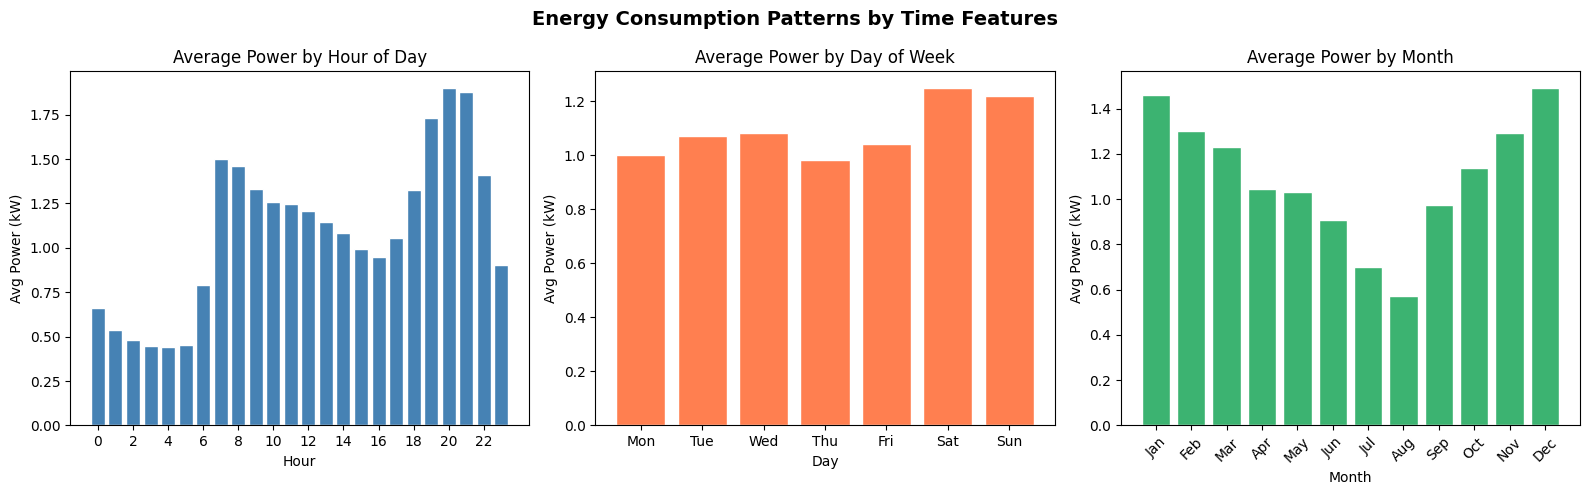

In [6]:
df_feat = df_hourly.to_frame(name='power')
df_feat['hour']       = df_feat.index.hour
df_feat['dayofweek']  = df_feat.index.dayofweek
df_feat['month']      = df_feat.index.month
df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Energy Consumption Patterns by Time Features', fontsize=14, fontweight='bold')

# Hour of day
hourly_avg = df_feat.groupby('hour')['power'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Power by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Power (kW)')
axes[0].set_xticks(range(0, 24, 2))

# Day of week
day_avg = df_feat.groupby('dayofweek')['power'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_labels, day_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Average Power by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Power (kW)')

# Month
month_avg = df_feat.groupby('month')['power'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_labels, month_avg.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Power by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Power (kW)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
TEST_HOURS = 7 * 24   # 168 hours

train = df_hourly[:-TEST_HOURS]
test  = df_hourly[-TEST_HOURS:]

print(f"Train: {len(train)} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {len(test)}  hours ({test.index.min().date()} → {test.index.max().date()})")

# Helper: evaluation metrics
def evaluate(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-9))) * 100
    print(f"\n{'='*40}")
    print(f"  {model_name} Results")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.4f} kW")
    print(f"  RMSE : {rmse:.4f} kW")
    print(f"  MAPE : {mape:.2f}%")
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'MAPE': round(mape,2)}

results = []

Train: 34000 hours (2006-12-16 → 2010-11-19)
Test : 168  hours (2010-11-19 → 2010-11-26)


Training ARIMA model...
ADF Statistic : -14.2046
p-value       : 0.0000
Series is stationary


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  ARIMA(5,1,2) Results
  MAE  : 0.6930 kW
  RMSE : 0.8555 kW
  MAPE : 122.36%


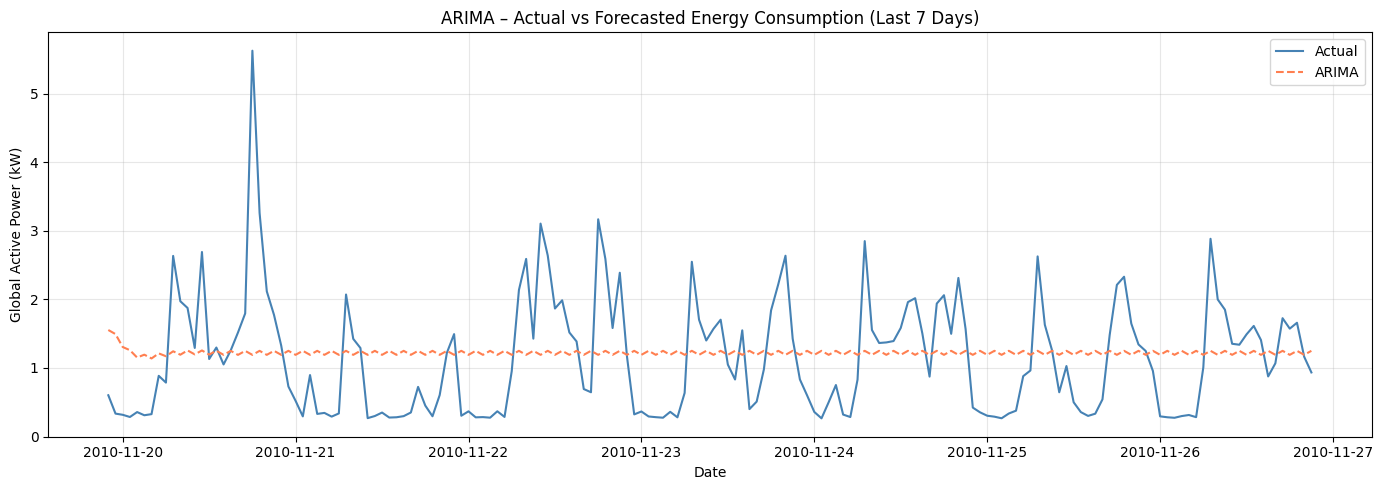

In [8]:
print("Training ARIMA model...")

# Stationarity check
adf_result = adfuller(train.values)
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Series is {'stationary' if adf_result[1] < 0.05 else 'non-stationary ❌'}")

# Use last 500 points for ARIMA (faster training)
train_arima = train[-500:]

arima_model = ARIMA(train_arima.values, order=(5, 1, 2))
arima_fit   = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=TEST_HOURS)
arima_forecast = np.clip(arima_forecast, 0, None)   # no negative power

result_arima = evaluate(test.values, arima_forecast, 'ARIMA(5,1,2)')
results.append(result_arima)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.values,         label='Actual',   color='steelblue', linewidth=1.5)
plt.plot(test.index, arima_forecast,      label='ARIMA',    color='coral',     linewidth=1.5, linestyle='--')
plt.title('ARIMA – Actual vs Forecasted Energy Consumption (Last 7 Days)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Training Prophet model...

  Prophet Results
  MAE  : 0.6070 kW
  RMSE : 0.7604 kW
  MAPE : 110.09%


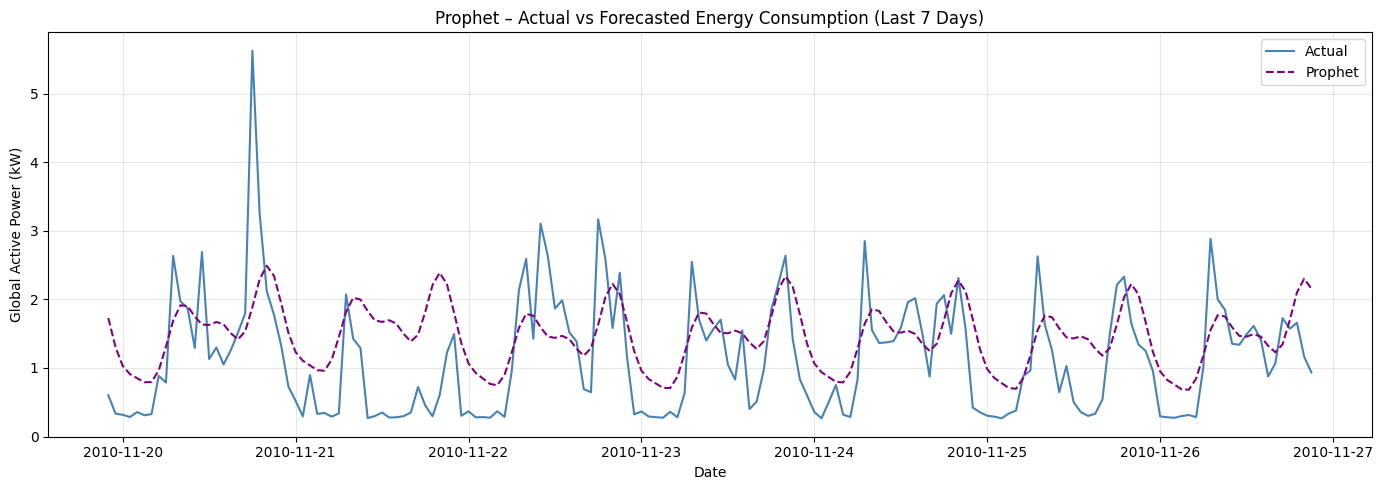

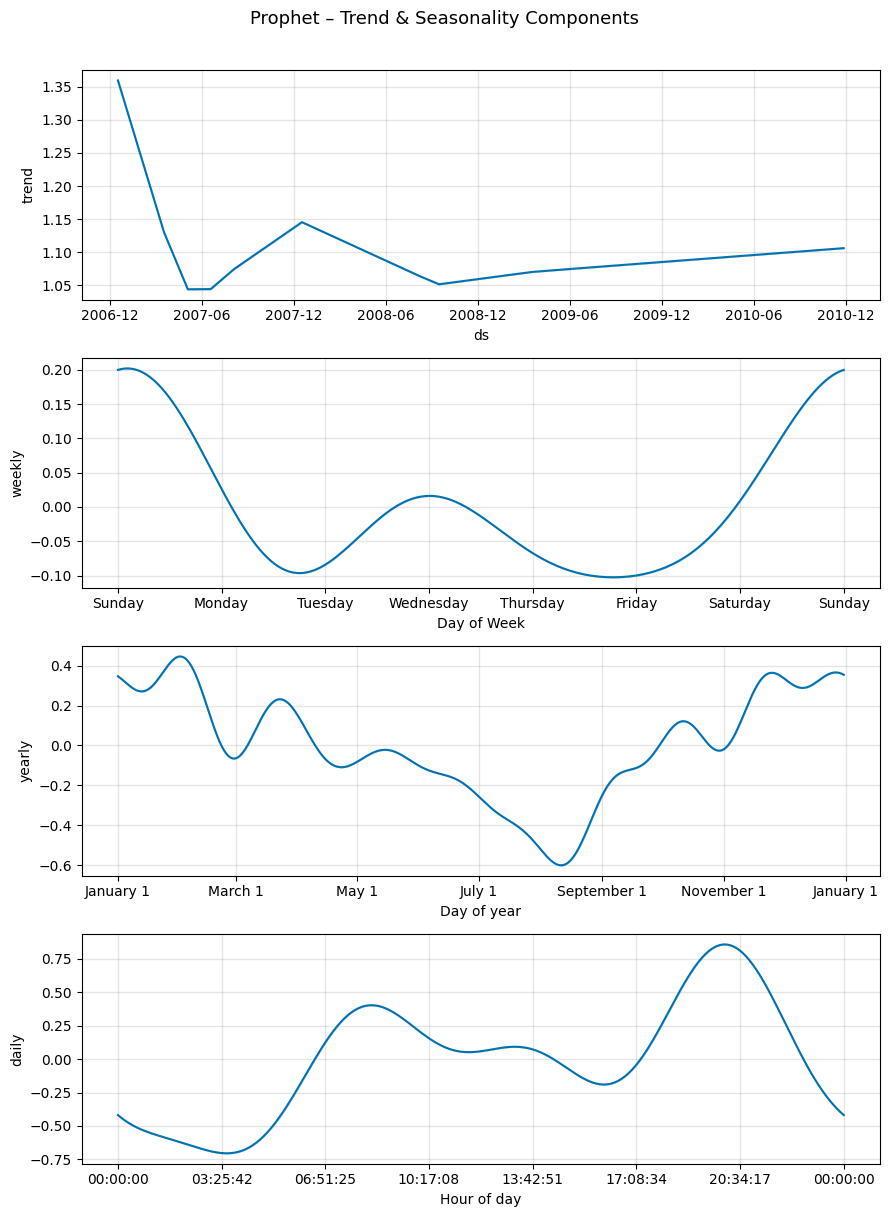

In [9]:
print("Training Prophet model...")

# Prophet needs columns 'ds' and 'y'
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=TEST_HOURS, freq='H')
forecast_df = prophet_model.predict(future)

# Extract only test period predictions
prophet_forecast = forecast_df['yhat'].values[-TEST_HOURS:]
prophet_forecast  = np.clip(prophet_forecast, 0, None)

result_prophet = evaluate(test.values, prophet_forecast, 'Prophet')
results.append(result_prophet)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.values,       label='Actual',   color='steelblue', linewidth=1.5)
plt.plot(test.index, prophet_forecast,  label='Prophet',  color='purple',    linewidth=1.5, linestyle='--')
plt.title('Prophet – Actual vs Forecasted Energy Consumption (Last 7 Days)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prophet components plot
fig2 = prophet_model.plot_components(forecast_df)
plt.suptitle('Prophet – Trend & Seasonality Components', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Training XGBoost model...

  XGBoost Results
  MAE  : 0.3569 kW
  RMSE : 0.5521 kW
  MAPE : 44.14%


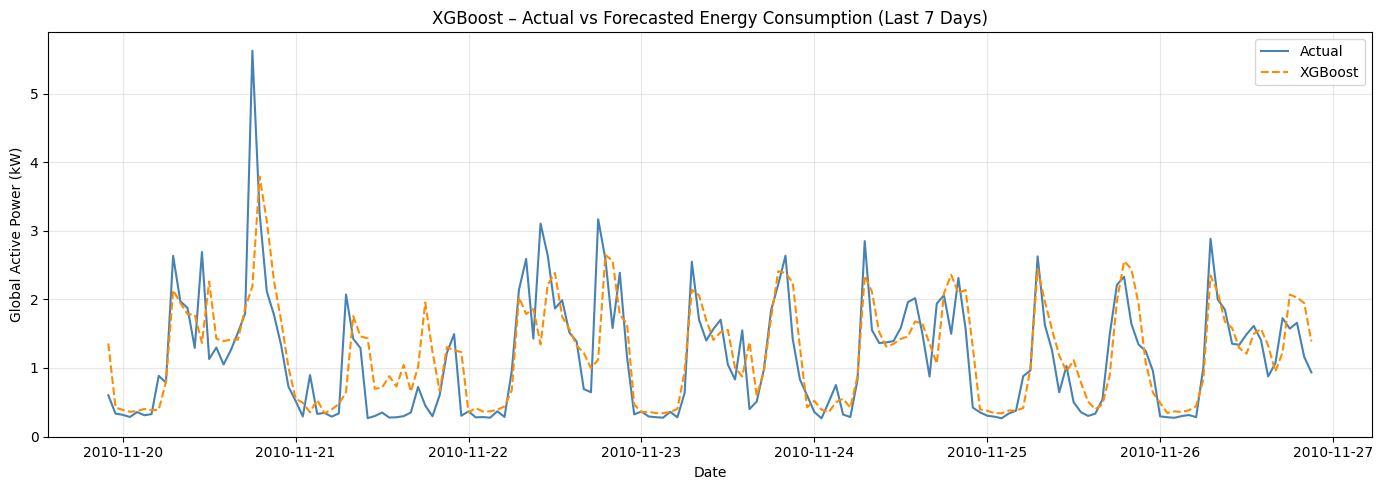

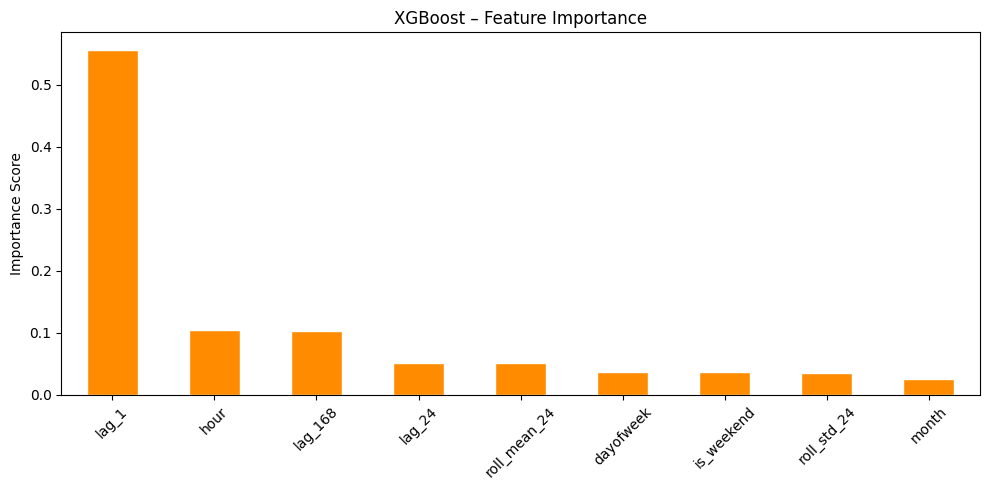

In [10]:
print("Training XGBoost model...")

# Feature engineering function
def make_features(series):
    df_x = series.to_frame(name='power')
    df_x['hour']        = df_x.index.hour
    df_x['dayofweek']   = df_x.index.dayofweek
    df_x['month']       = df_x.index.month
    df_x['is_weekend']  = df_x['dayofweek'].isin([5, 6]).astype(int)
    df_x['lag_1']       = df_x['power'].shift(1)
    df_x['lag_24']      = df_x['power'].shift(24)
    df_x['lag_168']     = df_x['power'].shift(168)   # 1 week
    df_x['roll_mean_24']= df_x['power'].shift(1).rolling(24).mean()
    df_x['roll_std_24'] = df_x['power'].shift(1).rolling(24).std()
    return df_x

# Build full feature set
full_series  = pd.concat([train, test])
df_features  = make_features(full_series)
df_features.dropna(inplace=True)

FEATURES = ['hour', 'dayofweek', 'month', 'is_weekend',
            'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_std_24']

# Split
train_xgb = df_features.loc[train.index.intersection(df_features.index)]
test_xgb  = df_features.loc[test.index.intersection(df_features.index)]

X_train = train_xgb[FEATURES]
y_train = train_xgb['power']
X_test  = test_xgb[FEATURES]
y_test  = test_xgb['power']

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_forecast = xgb_model.predict(X_test)
xgb_forecast  = np.clip(xgb_forecast, 0, None)

result_xgb = evaluate(y_test.values, xgb_forecast, 'XGBoost')
results.append(result_xgb)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test_xgb.index, y_test.values,    label='Actual',   color='steelblue', linewidth=1.5)
plt.plot(test_xgb.index, xgb_forecast,     label='XGBoost',  color='darkorange', linewidth=1.5, linestyle='--')
plt.title('XGBoost – Actual vs Forecasted Energy Consumption (Last 7 Days)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('XGBoost – Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

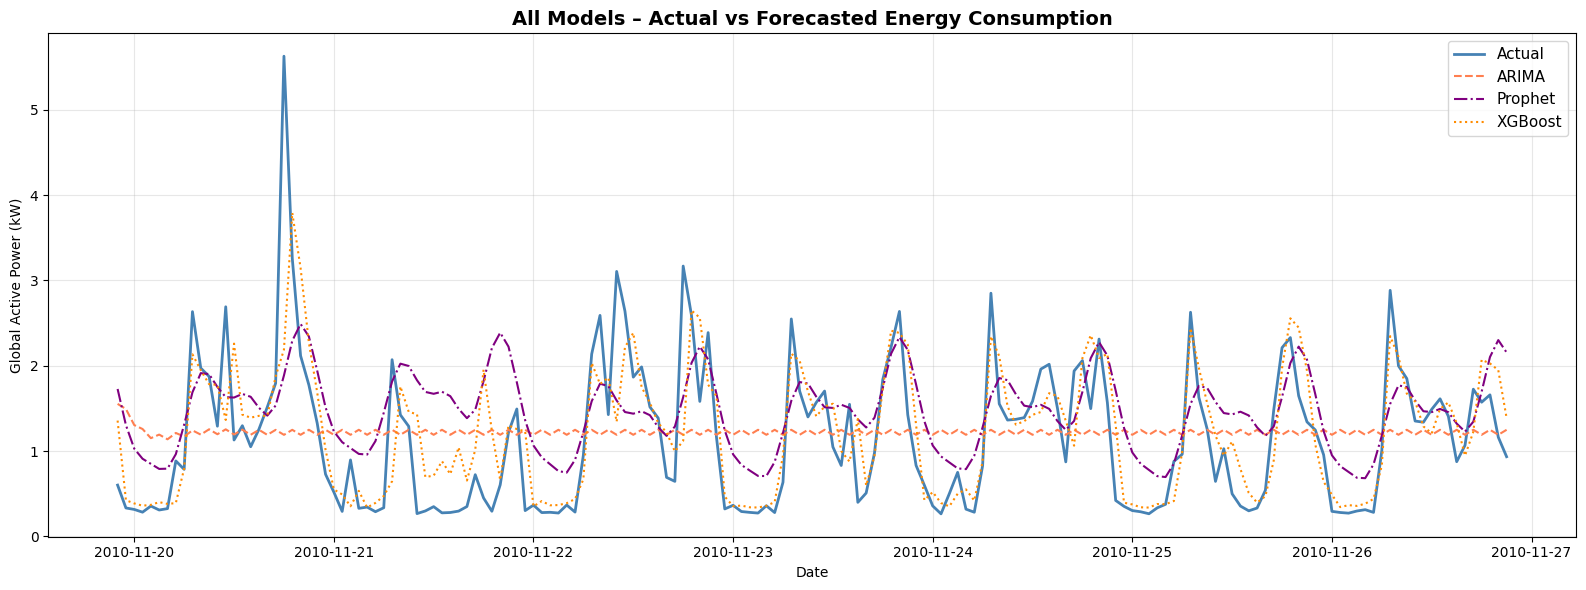

In [11]:
common_index    = test_xgb.index
actual_aligned  = y_test.values
arima_aligned   = arima_forecast[-len(common_index):]
prophet_aligned = prophet_forecast[-len(common_index):]
xgb_aligned     = xgb_forecast

plt.figure(figsize=(16, 6))
plt.plot(common_index, actual_aligned,   label='Actual',   color='steelblue',  linewidth=2)
plt.plot(common_index, arima_aligned,    label='ARIMA',    color='coral',      linewidth=1.5, linestyle='--')
plt.plot(common_index, prophet_aligned,  label='Prophet',  color='purple',     linewidth=1.5, linestyle='-.')
plt.plot(common_index, xgb_aligned,      label='XGBoost',  color='darkorange', linewidth=1.5, linestyle=':')
plt.title('All Models – Actual vs Forecasted Energy Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



=== Model Comparison ===
       Model    MAE   RMSE   MAPE
ARIMA(5,1,2) 0.6930 0.8555 122.36
     Prophet 0.6070 0.7604 110.09
     XGBoost 0.3569 0.5521  44.14


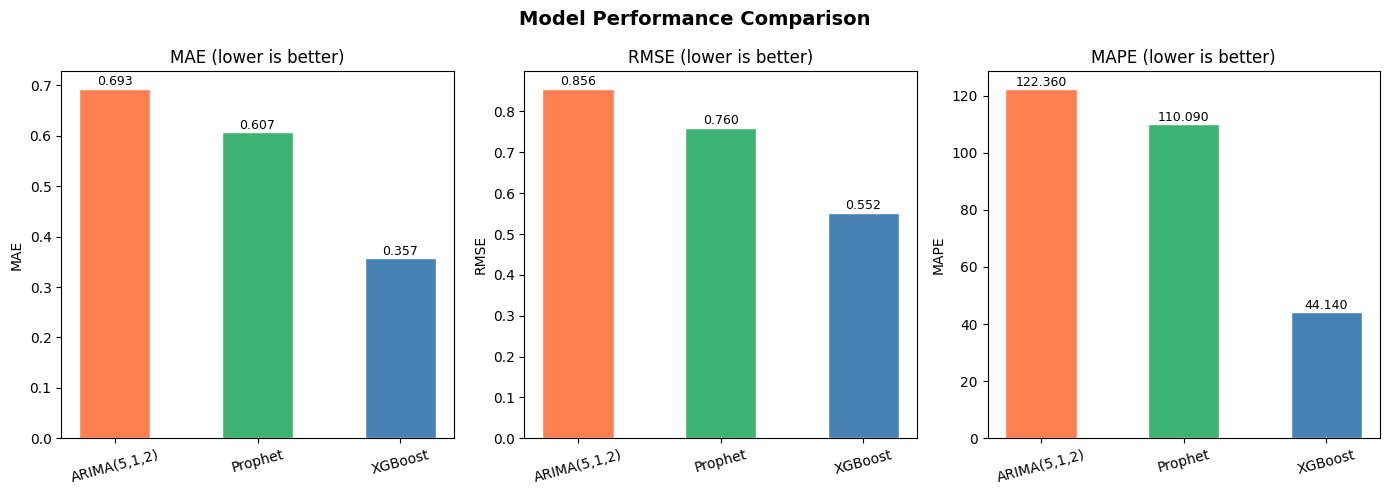

In [12]:
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['coral', 'mediumseagreen', 'steelblue']

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(results_df['Model'], results_df[metric],
                         color=colors, edgecolor='white', width=0.5)
    axes[idx].set_title(f'{metric} (lower is better)')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.001,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
best_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']

print("\n" + "="*55)
print("         TASK 3 – FINAL SUMMARY")
print("="*55)
print(f"  Dataset       : Household Power Consumption")
print(f"  Granularity   : Hourly resampled")
print(f"  Train period  : {train.index.min().date()} → {train.index.max().date()}")
print(f"  Test period   : {test.index.min().date()}  → {test.index.max().date()}")
print(f"  Test horizon  : 7 days ({TEST_HOURS} hours)")
print()
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} MAE={row['MAE']:.4f}  RMSE={row['RMSE']:.4f}  MAPE={row['MAPE']:.2f}%")
print()
print(f"Best Model : {best_model} (lowest RMSE)")
print()
print("Time series parsed and resampled")
print("Time-based features engineered")
print("ARIMA, Prophet, XGBoost trained")
print("Actual vs Forecasted plots generated")
print("MAE and RMSE evaluated for all models")
print("="*55)


         TASK 3 – FINAL SUMMARY
  Dataset       : Household Power Consumption
  Granularity   : Hourly resampled
  Train period  : 2006-12-16 → 2010-11-19
  Test period   : 2010-11-19  → 2010-11-26
  Test horizon  : 7 days (168 hours)

  ARIMA(5,1,2)           MAE=0.6930  RMSE=0.8555  MAPE=122.36%
  Prophet                MAE=0.6070  RMSE=0.7604  MAPE=110.09%
  XGBoost                MAE=0.3569  RMSE=0.5521  MAPE=44.14%

Best Model : XGBoost (lowest RMSE)

Time series parsed and resampled
Time-based features engineered
ARIMA, Prophet, XGBoost trained
Actual vs Forecasted plots generated
MAE and RMSE evaluated for all models
